In [14]:

includePreliminaryMessage = True
'''
Options:
2012
2015
2018
'''
year = 2012
'''
Options (depending on year): 
EPOS-LHC [2012, 2018]
QGSJET-II-04 [2012, 2018]
SIBYLL2.1 [2012, 2015]
SIBYLL2.3 [2012]
SIBYLL2.3d [2018]
'''
model = 'SIBYLL2.1'

## Set-Up

In [15]:
# Import libraries
import os, getpass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtran

from pandas import DataFrame
from collections import defaultdict

In [16]:
# Load in the SIBYLL2.1 particle sims - note that these will also be your variable names
KEYS = ['energy', 'particle_type', 'hits', 'reco_pass', 'showerplane_zen', 'laputop_zen', 'true_zenith', 'showerplane_az', 'laputop_az', 'true_azimuth', 'Hweights', 'Gweights']

for key in KEYS:
    if os.path.isfile(f'/data/user/tfutrell/it_anisotropy/{year}/{model}/{key}.npy'):
        with open(f'/data/user/tfutrell/it_anisotropy/{year}/{model}/{key}.npy', 'rb') as file:
            globals()[key] = np.load(file)
    else:
        print(f'{key}.npy does not exist or is not in the required folder.')

# Load in the in-ice data
d = np.load("/data/user/juancarlos/notebooks/dst_20904_v3.npz")

In [17]:
# Define a function for weighted medians, or weighted quantiles
def weighted_quantiles(values, weights, quantiles=0.5):
    if len(values) == 0:
        return 0
    else:
        i = np.argsort(values)
        c = np.cumsum(weights[i])
        return values[i[np.searchsorted(c, np.array(quantiles) * c[-1])]]

In [18]:
# Dictionary set-ups
# Set up composition-dependent dictionaries based on year and interaction model (some only have Fe and p)
if year == 2012 and (model == 'EPOS-LHC' or model == 'SIBYLL2.3' or model == 'QGSJET-II-04'):
    # Cuts for different compositions
    COMPS = {
        'proton': particle_type == 2.21200000e+03,
        'iron': particle_type == 1.00026056e+09,
        'true': np.tile(True, len(energy))
    }

    # Graph colors by composition
    COLORS = {
        'true' : 'black',
        'proton': 'red',
        'iron': 'blue'
    }

    # Graph labels by composition
    LABEL = {
        'true' : 'Data',
        'proton': 'p',
        'iron': 'Fe'
    }
else:
    # Cuts for different compositions
    COMPS = {
        'proton': particle_type == 2.21200000e+03,
        'helium' : particle_type == 1.00002004e+09,
        'oxygen': particle_type == 1.00008016e+09,
        'iron': particle_type == 1.00026056e+09,
        'true': np.tile(True, len(energy))
    }


    # Graph labels by composition
    LABEL = {
        'true' : 'Data',
        'proton': 'p',
        'helium': 'He',
        'oxygen': 'O',
        'iron': 'Fe'
    }

# amu of different compositions
A = {
    'proton': 1.0073,
    'helium': 4.0026,
    'oxygen': 16,
    'iron': 55.845  
}

# Number of protons for different compositions
Z = {
    'proton': 1,
    'helium': 2,
    'nitrogen': 7,
    'oxygen': 8,
    'aluminum': 13,
    'iron': 26
}

# IceTop Tiers and quality cuts - quality cuts may not work well with some years and Tiers (e.g. reco_succeeded cancels out Tier 4 for 2012)
tier1_quality_cuts = (showerplane_zen < np.radians(55))
quality_cuts = (laputop_zen < np.radians(55)) * (reco_pass == 1)

# Calculation for the Tier offset per year
offset = np.ceil((year - 2011)/2)

if year < 2015:
    TIERS = {
        'Tier 1': (3 <= hits) * (hits < 5),
        'Tier 2': (5 <= hits) * (hits < 10 - offset),
        'Tier 3': (10 - offset <= hits) * (hits < 17 - offset),
        'Tier 4': (17 - offset <= hits)
    }

else:
    TIERS = {
        'Tier 3': (10 - offset <= hits) * (hits < 17 - offset),
        'Tier 4': (17 - offset <= hits)
    }

# Weights
SIMS = {
    'GSF': Gweights
}


# Dictionary for total flux times log(Z) and for total flux across compositions for each Tier and weight.
# 3-level nested defaultdict: d['key1']['key2']['key3'] = np.zeros(nbins)
TOTALS = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: np.zeros(nbins))))

# Table for partial compositions, ln(A), median log of rigidity and energy for each Tier and weight
TABLE = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

IC_COMPS = {
    'proton': d['type'] == 2212,
    'helium': d['type'] == 1.00002004e+09,
    'nitrogen': d['type'] == 1.000070140e+09,
    'aluminum': d['type'] == 1.00013027e+09,
    'iron': d['type'] == 1.00026056e+09
}


In [19]:
# Calculate log10(rigidity)
# The -3 is to scale energy to TeV
rigidity = np.log10(energy) - 3
for comp, comp_cut in COMPS.items():
    if not comp == 'true':
        rigidity[comp_cut] -= np.log10(Z[comp])

ic_rigidity = np.log10(d['mc_energy']) - 3
for comp, comp_cut in IC_COMPS.items():
    if not comp == 'true':
        ic_rigidity[comp_cut] -= np.log10(Z[comp])

## Weighted rate vs. energy

Tier 1
--------------------------
GSF
    proton
        Median: 0.273 PeV
        68%: 0.131-0.28 PeV

    iron
        Median: 0.386 PeV
        68%: 0.19-0.401 PeV

    true
        Median: 0.298 PeV
        68%: 0.143-0.315 PeV

Tier 2
--------------------------
GSF
    proton
        Median: 0.807 PeV
        68%: 0.418-0.843 PeV

    iron
        Median: 1.149 PeV
        68%: 0.542-1.228 PeV

    true
        Median: 0.898 PeV
        68%: 0.465-0.969 PeV

Tier 3
--------------------------
GSF
    proton
        Median: 2.013 PeV
        68%: 0.864-1.873 PeV

    iron
        Median: 2.833 PeV
        68%: 1.246-3.197 PeV

    true
        Median: 2.275 PeV
        68%: 1.016-2.203 PeV

Tier 4
--------------------------
GSF
    proton
        Median: 5.791 PeV
        68%: 2.338-6.555 PeV

    iron
        Median: 8.743 PeV
        68%: 4.135-13.727 PeV

    true
        Median: 6.554 PeV
        68%: 2.768-8.374 PeV



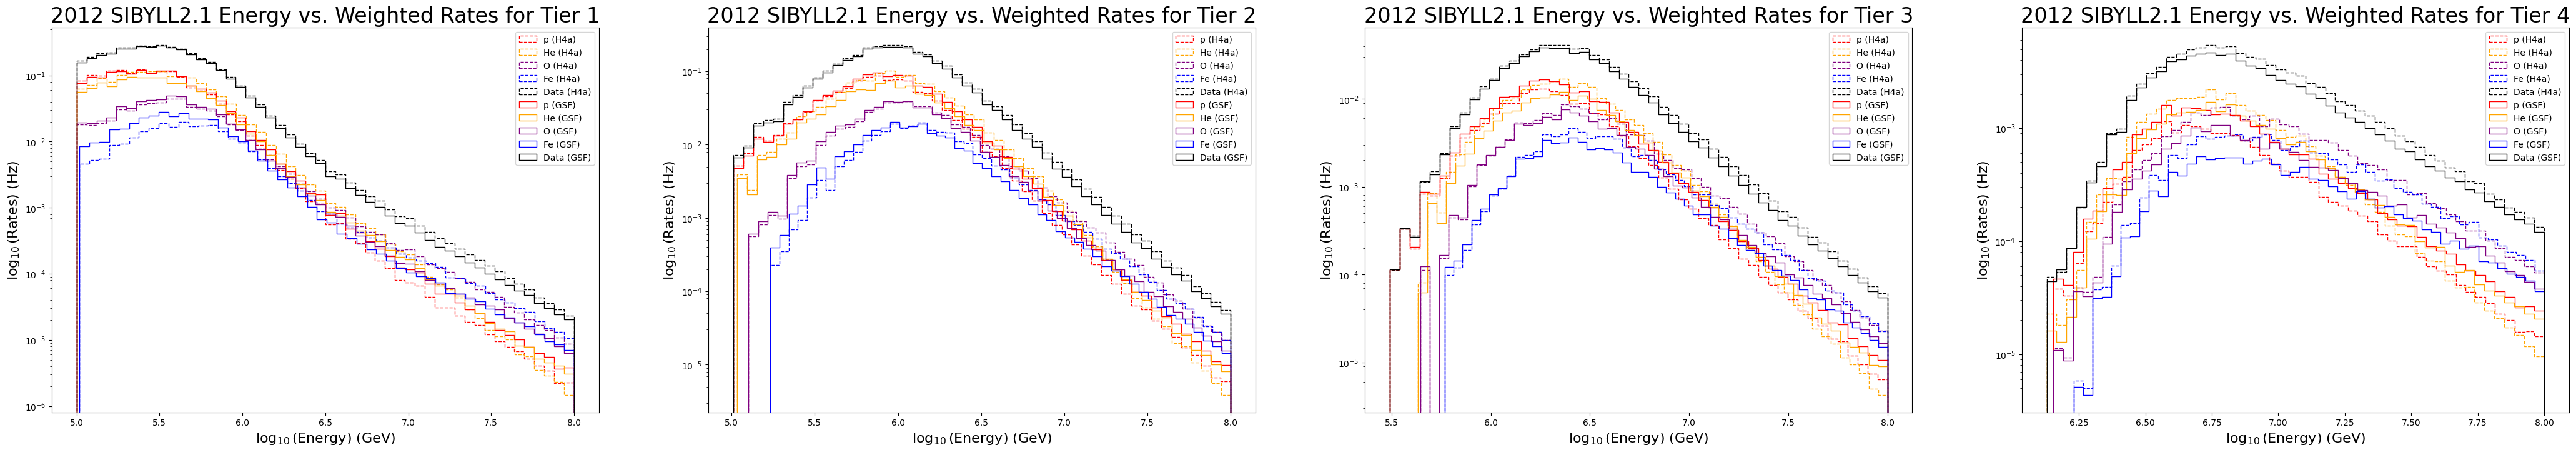

In [20]:
# Prepare the graphs


for tier, tier_cut, ax in zip(TIERS.keys(), TIERS.values(), axs):
    # Print Tier for table
    print(tier)
    print('--------------------------')
    
    for weight_name, weights in SIMS.items():
        # Print weights for table
        print(weight_name)

        for comp, comp_cut in COMPS.items():
            # Combine cuts
            combined_cut = comp_cut * tier_cut

            if year == 2012:
                if tier == 'Tier 1':
                    combined_cut *= (showerplane_zen < np.radians(55))
                else:
                    combined_cut *= tier1_quality_cuts
            elif year == 2015:
                if tier =='Tier 3':
                    combined_cut *= (laputop_zen < np.radians(55))
                else:
                    combined_cut *= quality_cuts
            else:
                combined_cut *= quality_cuts

           
            # Print median energy and its first sigma
            if comp == 'proton' or comp == 'iron' or comp == 'true':
                median = weighted_quantiles(energy[combined_cut], weights[combined_cut])
                print(f'    {comp}')
                print(f'        Median: {round(median/1e6, 3)} PeV')
                print(f'        68%: {round((median-weighted_quantiles(energy[combined_cut], weights[combined_cut], quantiles=.16))/1e6, 3)}-{round((weighted_quantiles(energy[combined_cut], weights[combined_cut], .84)-median)/1e6, 3)} PeV')
                print()

